# Siamese CNN Training for Fragmented ID Resolution

This notebook trains an end-to-end Siamese network that:
1. Takes raw text pairs as input
2. Embeds both with a shared CharCNN encoder
3. Classifies whether they're duplicates

In [1]:
# Imports and Setup
import os
import sys
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

# Import custom modules
sys.path.append('src')
from model import CharCNNEncoder
from model_utils import char_to_idx, vocab_size
from pair_text_dataset import PairTextDataset
from siamese_cnn import SiameseCNN
from siamese_train_utils import train_epoch, evaluate, print_evaluation_report

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Vocab size: {vocab_size}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda
Vocab size: 38


In [ ]:

# ============================================================================
# UTILITY FUNCTIONS FOR DATA LOADING, TRAINING, AND EVALUATION
# ============================================================================

def load_and_create_datasets(train_path, val_path, test_path, features, max_len=100, batch_size=128):
    """Load CSV files and create datasets with DataLoaders"""
    print("\n" + "="*60)
    print(f"LOADING DATA: {train_path}, {val_path}, {test_path}")
    print("="*60)
    
    # Load data
    train_data = pd.read_csv(train_path)
    val_data = pd.read_csv(val_path)
    test_data = pd.read_csv(test_path)
    
    # Create datasets
    train_dataset = PairTextDataset(data=train_data, char_to_idx=char_to_idx, max_len=max_len, features=features)
    val_dataset = PairTextDataset(data=val_data, char_to_idx=char_to_idx, max_len=max_len, features=features)
    test_dataset = PairTextDataset(data=test_data, char_to_idx=char_to_idx, max_len=max_len, features=features)
    
    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    print(f"\nDataLoaders created:")
    print(f"  Train batches: {len(train_loader)}")
    print(f"  Val batches: {len(val_loader)}")
    print(f"  Test batches: {len(test_loader)}")
    
    return train_loader, val_loader, test_loader


def train_and_evaluate_model(train_loader, val_loader, model_name, epochs=30, learning_rate=0.001):
    """Initialize, train, and evaluate a Siamese CNN model"""
    print("\n" + "="*60)
    print(f"TRAINING MODEL: {model_name}")
    print("="*60)
    
    # Hyperparameters
    EMBED_DIM = 32
    NUM_FILTERS = 128
    KERNEL_SIZES = (3, 4, 5)
    DROPOUT = 0.3
    CNN_OUTPUT_DIM = 128
    
    # Initialize model
    model = SiameseCNN(
        vocab_size=vocab_size,
        embed_dim=EMBED_DIM,
        num_filters=NUM_FILTERS,
        kernel_sizes=KERNEL_SIZES,
        dropout=DROPOUT,
        cnn_output_dim=CNN_OUTPUT_DIM
    ).to(device)
    
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3, factor=0.5)
    
    # Training history
    history = {'train_loss': [], 'train_acc': [], 'train_f1': [], 
               'val_loss': [], 'val_acc': [], 'val_f1': []}
    best_val_f1 = 0.0
    best_epoch = 0
    
    os.makedirs('models', exist_ok=True)
    
    # Training loop
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        
        train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_f1, val_labels, val_preds, val_probs = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        
        print(f"Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}")
        print(f"Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")
        
        scheduler.step(val_f1)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Learning Rate: {current_lr:.6f}")
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch + 1
            model_path = f'models/best_{model_name}.pth'
            torch.save(model.state_dict(), model_path)
            print(f"🎯 NEW BEST F1: {best_val_f1:.4f}")
    
    print(f"\nBest Validation F1: {best_val_f1:.4f} (Epoch {best_epoch})")
    
    return model, history, best_val_f1, best_epoch


def plot_and_save_history(history, model_name, title):
    """Plot and save training history"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Loss - {title}', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(history['train_acc'], label='Train Acc', marker='o', linewidth=2)
    axes[1].plot(history['val_acc'], label='Val Acc', marker='s', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'Accuracy - {title}', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    best_f1 = max(history['val_f1'])
    axes[2].plot(history['train_f1'], label='Train F1', marker='o', linewidth=2)
    axes[2].plot(history['val_f1'], label='Val F1', marker='s', linewidth=2)
    axes[2].axhline(y=best_f1, color='r', linestyle='--', linewidth=2, label=f'Best F1: {best_f1:.4f}')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1 Score')
    axes[2].set_title(f'F1 Score - {title}', fontweight='bold')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plot_path = f'training_history_{model_name}.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Training history plot saved as '{plot_path}'")
    
    # Save history as CSV
    history_df = pd.DataFrame(history)
    csv_path = f'training_history_{model_name}.csv'
    history_df.to_csv(csv_path, index=False)
    print(f"Training history CSV saved as '{csv_path}'")


def evaluate_on_test(model, test_loader, model_name, criterion, device):
    """Evaluate model on test set and save results"""
    print("\n" + "="*60)
    print(f"EVALUATING {model_name.upper()} ON TEST SET")
    print("="*60)
    
    model.eval()
    test_loss, test_acc, test_f1, test_labels, test_preds, test_probs = evaluate(
        model, test_loader, criterion, device
    )
    cm, precision, recall, specificity, final_f1 = print_evaluation_report(
        test_labels, test_preds, test_probs
    )
    
    # Save results
    tn, fp, fn, tp = cm.ravel()
    with open(f'test_results_{model_name}.txt', 'w') as f:
        f.write("="*60 + "\n")
        f.write(f"TEST RESULTS - {model_name.upper()}\n")
        f.write("="*60 + "\n\n")
        f.write("Test Metrics:\n")
        f.write(f"  Loss: {test_loss:.4f}\n")
        f.write(f"  Accuracy: {test_acc:.4f}\n")
        f.write(f"  F1 Score: {final_f1:.4f}\n")
        f.write(f"  Precision: {precision:.4f}\n")
        f.write(f"  Recall: {recall:.4f}\n")
        f.write(f"  Specificity: {specificity:.4f}\n\n")
        f.write("Confusion Matrix:\n")
        f.write(f"  TN={tn:6d}  FP={fp:6d}\n")
        f.write(f"  FN={fn:6d}  TP={tp:6d}\n")
    
    print(f"Test results saved to 'test_results_{model_name}.txt'")
    
    return test_loss, test_acc, final_f1, precision, recall, specificity


def load_model_and_validate(model_name, val_loader, criterion, device):
    """Load model and evaluate on validation set"""
    print("\n" + "="*60)
    print(f"VALIDATING {model_name.upper()}")
    print("="*60)
    
    model = SiameseCNN(
        vocab_size=vocab_size,
        embed_dim=32,
        num_filters=128,
        kernel_sizes=(3, 4, 5),
        dropout=0.3,
        cnn_output_dim=128
    ).to(device)
    
    model_path = f'models/best_{model_name}.pth'
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    val_loss, val_acc, val_f1, val_labels, val_preds, val_probs = evaluate(
        model, val_loader, criterion, device
    )
    
    cm, precision, recall, specificity, final_f1 = print_evaluation_report(
        val_labels, val_preds, val_probs
    )
    
    print(f"\nValidation Results:")
    print(f"  Loss: {val_loss:.4f}")
    print(f"  Accuracy: {val_acc:.4f}")
    print(f"  F1 Score: {final_f1:.4f}")
    
    return model, cm, precision, recall, specificity, final_f1


In [2]:
!git checkout Arpith 

M	Siamese_testing.ipynb
M	src/__pycache__/model.cpython-312.pyc
M	src/__pycache__/model_utils.cpython-312.pyc
Your branch is ahead of 'origin/Arpith' by 1 commit.
  (use "git push" to publish your local commits)


Already on 'Arpith'


In [3]:
train_aug_data = pd.read_csv('data/train_pairs_aug.csv')
val_aug_data = pd.read_csv('data/val_pairs_aug.csv')
test_aug_data = pd.read_csv('data/test_pairs_aug.csv')
val_noaug_data = pd.read_csv('data/val_pairs.csv')
test_noaug_data = pd.read_csv('data/test_pairs.csv')

C:\Users\arpit\AppData\Local\Temp\ipykernel_17836\1818582478.py:1: DtypeWarning: Columns (42) have mixed types. Specify dtype option on import or set low_memory=False.
  train_aug_data = pd.read_csv('data/train_pairs_aug.csv')


Use PairTextDataset to seperate ID1 and ID2 info, tokenize and load data in batches

In [ ]:
# Define features and hyperparameters
FEATURES = ['first_name', 'midl_name', 'last_name', 'age', 'sex', 'street_name', 'zip_code', 'house_num', 'area_cd']
MAX_LEN = 100
BATCH_SIZE = 128
EPOCHS = 30

# Load augmented data and create DataLoaders
train_loader, val_loader, test_loader = load_and_create_datasets(
    'data/train_pairs_aug.csv',
    'data/val_pairs_aug.csv',
    'data/test_pairs_aug.csv',
    features=FEATURES,
    max_len=MAX_LEN,
    batch_size=BATCH_SIZE
)


CREATING DATASETS

Loaded 65503 pairs from the data
  - Duplicates: 13652
  - Non-duplicates: 51851
  - Using features: ['first_name', 'midl_name', 'last_name', 'age', 'sex', 'street_name', 'zip_code', 'house_num', 'area_cd']

Loaded 6901 pairs from the data
  - Duplicates: 2938
  - Non-duplicates: 3963
  - Using features: ['first_name', 'midl_name', 'last_name', 'age', 'sex', 'street_name', 'zip_code', 'house_num', 'area_cd']

DataLoaders created:
  Train batches: 512
  Val batches: 54

Test batch shapes:
  seq1: torch.Size([128, 100])
  seq2: torch.Size([128, 100])
  labels: torch.Size([128])


In [ ]:
# Train augmented model
criterion = nn.BCELoss()
model, history, best_val_f1, best_epoch = train_and_evaluate_model(
    train_loader, val_loader, 
    model_name='siamese_cnn',
    epochs=EPOCHS,
    learning_rate=0.001
)


INITIALIZING MODEL

Model Summary:
  Total parameters: 273,601
  Trainable parameters: 273,601

Hyperparameters:
  Batch size: 128
  Learning rate: 0.001
  Epochs: 30
  CNN output dim: 128


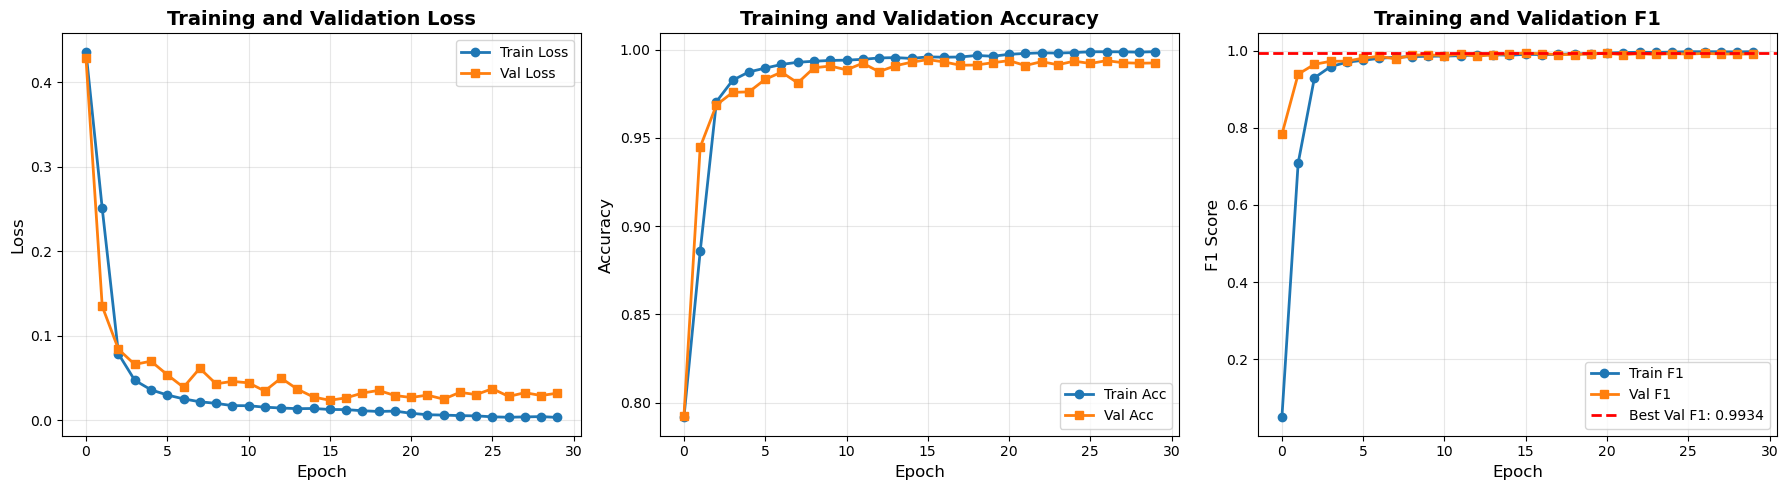


Training history plot saved as 'training_history.png'


In [ ]:
# Plot and save training history
plot_and_save_history(history, 'siamese_cnn', 'Augmented Training')

In [ ]:
# Load and validate augmented model
model, cm, precision, recall, specificity, final_f1 = load_model_and_validate(
    'siamese_cnn', val_loader, criterion, device
)


LOADING BEST MODEL FOR FINAL EVALUATION



FINAL VALIDATION RESULTS (BEST MODEL)
Loss: 0.0235
Accuracy: 0.9943
F1 Score: 0.9934

DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

Non-Duplicate     0.9992    0.9909    0.9951      3963
    Duplicate     0.9879    0.9990    0.9934      2938

     accuracy                         0.9943      6901
    macro avg     0.9936    0.9949    0.9942      6901
 weighted avg     0.9944    0.9943    0.9944      6901


Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual  Neg     3927     36
        Pos        3   2935

Additional Metrics:
  Precision: 0.9879
  Recall (Sensitivity): 0.9990
  Specificity: 0.9909
  F1 Score: 0.9934


In [ ]:
# Save final results for augmented model
tn, fp, fn, tp = cm.ravel()
with open('final_results_siamese_cnn.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("SIAMESE CNN FINAL RESULTS\n")
    f.write("="*60 + "\n\n")
    f.write(f"Best Epoch: {best_epoch}\n")
    f.write(f"Best Validation F1: {best_val_f1:.4f}\n\n")
    f.write("Final Validation Metrics:\n")
    f.write(f"  F1 Score: {final_f1:.4f}\n")
    f.write(f"  Precision: {precision:.4f}\n")
    f.write(f"  Recall: {recall:.4f}\n")
    f.write(f"  Specificity: {specificity:.4f}\n\n")
    f.write("Confusion Matrix:\n")
    f.write(f"  TN={tn:6d}  FP={fp:6d}\n")
    f.write(f"  FN={fn:6d}  TP={tp:6d}\n")

print("Final results saved to 'final_results_siamese_cnn.txt'")


Training history saved to 'training_history.csv'
Final results saved to 'final_results.txt'

ALL DONE! ✅


## Without Augmentation on Val and test


In [ ]:
# Load non-augmented data and create DataLoaders
train_loader_noaug, val_loader_noaug, test_loader_noaug = load_and_create_datasets(
    'data/train_pairs_aug.csv',
    'data/val_pairs.csv',
    'data/test_pairs.csv',
    features=FEATURES,
    max_len=MAX_LEN,
    batch_size=BATCH_SIZE
)


CREATING DATASETS (VAL: val_pairs.csv - NOT AUGMENTED)


c:\Users\arpit\spring-2026-deep-learning-fragmented-id-resolution\src\pair_text_dataset.py:24: DtypeWarning: Columns (42) have mixed types. Specify dtype option on import or set low_memory=False.
  self.pairs = pd.read_csv(pairs_csv_path)



Loaded 65503 pairs from data/train_pairs_aug.csv
  - Duplicates: 13652
  - Non-duplicates: 51851
  - Using features: ['first_name', 'midl_name', 'last_name', 'age', 'sex', 'street_name', 'zip_code', 'house_num', 'area_cd']

Loaded 3573 pairs from data/val_pairs.csv
  - Duplicates: 1469
  - Non-duplicates: 2104
  - Using features: ['first_name', 'midl_name', 'last_name', 'age', 'sex', 'street_name', 'zip_code', 'house_num', 'area_cd']

DataLoaders created:
  Train batches: 512
  Val batches: 28

Test batch shapes:
  seq1: torch.Size([128, 100])
  seq2: torch.Size([128, 100])
  labels: torch.Size([128])


In [ ]:
# Train non-augmented validation model
model_noaug, history_noaug, best_val_f1_noaug, best_epoch_noaug = train_and_evaluate_model(
    train_loader_noaug, val_loader_noaug,
    model_name='siamese_cnn_noaug_val',
    epochs=EPOCHS,
    learning_rate=0.001
)


INITIALIZING MODEL

Model Summary:
  Total parameters: 273,601
  Trainable parameters: 273,601

Hyperparameters:
  Batch size: 128
  Learning rate: 0.001
  Epochs: 30
  CNN output dim: 128


In [ ]:
# Training already completed from the previous cell
print("✅ Non-augmented model training completed!")


STARTING TRAINING

Epoch 1/30



Train - Loss: 0.4444, Acc: 0.7892, F1: 0.0242
Val   - Loss: 0.4661, Acc: 0.7674, F1: 0.7324
Learning Rate: 0.001000

🎯 NEW BEST F1: 0.7324

Epoch 2/30



Train - Loss: 0.2809, Acc: 0.8670, F1: 0.6375
Val   - Loss: 0.2425, Acc: 0.8970, F1: 0.8883
Learning Rate: 0.001000

🎯 NEW BEST F1: 0.8883

Epoch 3/30



Train - Loss: 0.0924, Acc: 0.9660, F1: 0.9185
Val   - Loss: 0.0821, Acc: 0.9698, F1: 0.9645
Learning Rate: 0.001000

🎯 NEW BEST F1: 0.9645

Epoch 4/30



Train - Loss: 0.0505, Acc: 0.9820, F1: 0.9569
Val   - Loss: 0.0600, Acc: 0.9798, F1: 0.9760
Learning Rate: 0.001000

🎯 NEW BEST F1: 0.9760

Epoch 5/30


...


Train - Loss: 0.0039, Acc: 0.9987, F1: 0.9970
Val   - Loss: 0.0292, Acc: 0.9930, F1: 0.9915
Learning Rate: 0.000250

Epoch 27/30



Train - Loss: 0.0048, Acc: 0.9984, F1: 0.9963
Val   - Loss: 0.0244, Acc: 0.9927, F1: 0.9912
Learning Rate: 0.000250

Epoch 28/30



Train - Loss: 0.0039, Acc: 0.9987, F1: 0.9968
Val   - Loss: 0.0306, Acc: 0.9910, F1: 0.9892
Learning Rate: 0.000125

Epoch 29/30



Train - Loss: 0.0039, Acc: 0.9987, F1: 0.9969
Val   - Loss: 0.0252, Acc: 0.9933, F1: 0.9919
Learning Rate: 0.000125

Epoch 30/30



Train - Loss: 0.0032, Acc: 0.9989, F1: 0.9974
Val   - Loss: 0.0244, Acc: 0.9927, F1: 0.9912
Learning Rate: 0.000125

TRAINING COMPLETE!
Best Validation F1: 0.9922 (Epoch 25)


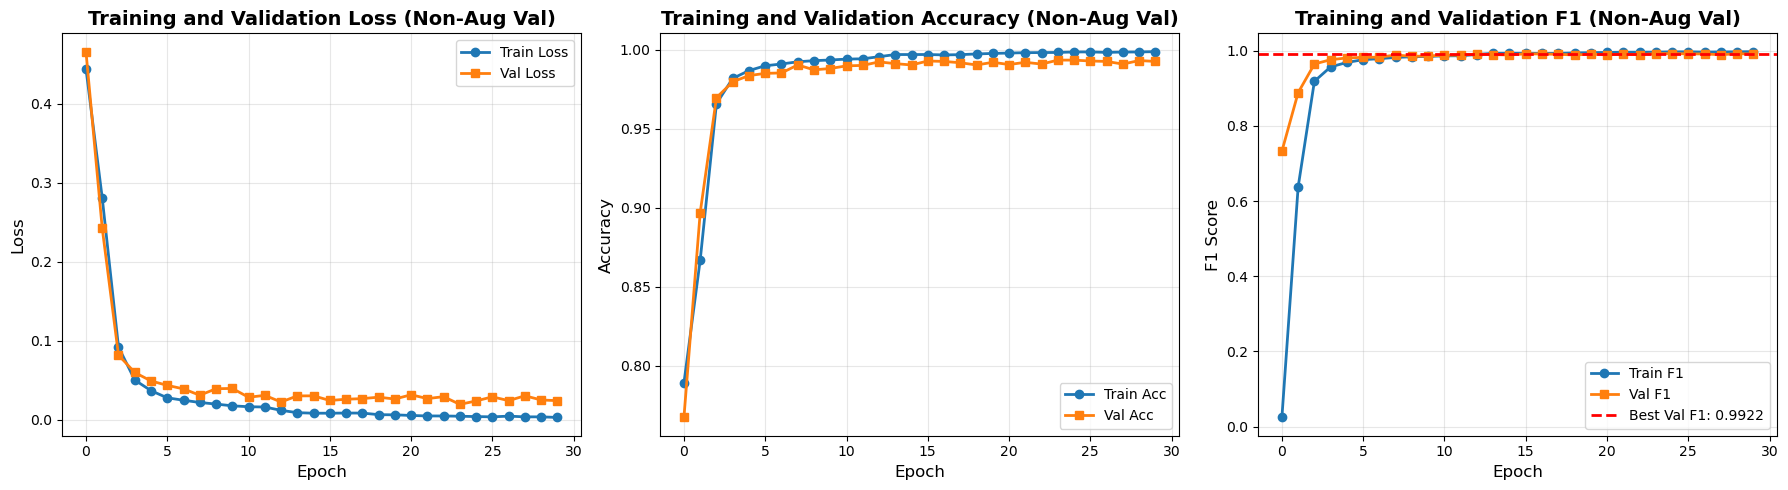


Training history plot saved as 'training_history_noaug_val.png'


In [ ]:
# Plot and save training history for non-augmented model
plot_and_save_history(history_noaug, 'siamese_cnn_noaug_val', 'Non-Augmented Validation')

In [ ]:
# Load and validate non-augmented model
model_noaug, cm_noaug, precision_noaug, recall_noaug, specificity_noaug, final_f1_noaug = load_model_and_validate(
    'siamese_cnn_noaug_val', val_loader_noaug, criterion, device
)


LOADING BEST MODEL FOR FINAL EVALUATION



FINAL VALIDATION RESULTS (BEST MODEL - NON-AUG VAL)
Loss: 0.0240
Accuracy: 0.9936
F1 Score: 0.9922

DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

Non-Duplicate     0.9990    0.9900    0.9945      2104
    Duplicate     0.9859    0.9986    0.9922      1469

     accuracy                         0.9936      3573
    macro avg     0.9925    0.9943    0.9934      3573
 weighted avg     0.9936    0.9936    0.9936      3573


Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual  Neg     2083     21
        Pos        2   1467

Additional Metrics:
  Precision: 0.9859
  Recall (Sensitivity): 0.9986
  Specificity: 0.9900
  F1 Score: 0.9922


In [ ]:
# Save final results for non-augmented validation model
tn, fp, fn, tp = cm_noaug.ravel()
with open('final_results_siamese_cnn_noaug_val.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("SIAMESE CNN NON-AUGMENTED VALIDATION RESULTS\n")
    f.write("="*60 + "\n\n")
    f.write(f"Best Epoch: {best_epoch_noaug}\n")
    f.write(f"Best Validation F1: {best_val_f1_noaug:.4f}\n\n")
    f.write("Final Validation Metrics:\n")
    f.write(f"  F1 Score: {final_f1_noaug:.4f}\n")
    f.write(f"  Precision: {precision_noaug:.4f}\n")
    f.write(f"  Recall: {recall_noaug:.4f}\n")
    f.write(f"  Specificity: {specificity_noaug:.4f}\n\n")
    f.write("Confusion Matrix:\n")
    f.write(f"  TN={tn:6d}  FP={fp:6d}\n")
    f.write(f"  FN={fn:6d}  TP={tp:6d}\n")

print("Final results saved to 'final_results_siamese_cnn_noaug_val.txt'")
print("\n" + "="*60)
print("AUGMENTED VS NON-AUGMENTED MODELS TRAINING COMPLETE! ✅")
print("="*60)


Training history saved to 'training_history_noaug_val.csv'
Final results saved to 'final_results_noaug_val.txt'

ALL DONE! ✅


In [ ]:
# Test loaders already created:
# - test_loader: augmented test set
# - test_loader_noaug: non-augmented test set
# - test_loader_hp: hard positives test set

print("\n" + "="*60)
print("TEST SET EVALUATION")
print("="*60)
print("\nTest loaders ready for evaluation")



CREATING TEST DATASETS

Loaded 7475 pairs from data/test_pairs_aug.csv
  - Duplicates: 3048
  - Non-duplicates: 4427
  - Using features: ['first_name', 'midl_name', 'last_name', 'age', 'sex', 'street_name', 'zip_code', 'house_num', 'area_cd']

Loaded 3870 pairs from data/test_pairs.csv
  - Duplicates: 1524
  - Non-duplicates: 2346
  - Using features: ['first_name', 'midl_name', 'last_name', 'age', 'sex', 'street_name', 'zip_code', 'house_num', 'area_cd']

Test DataLoaders created:
  Augmented test batches: 59
  Non-augmented test batches: 31


In [ ]:
# Evaluate augmented model on test sets
test_loss_aug, test_acc_aug, test_f1_aug, prec_aug_test, rec_aug_test, spec_aug_test = evaluate_on_test(
    model, test_loader, 'siamese_cnn_test_aug', criterion, device
)

test_loss_noaug, test_acc_noaug, test_f1_noaug, prec_aug_noaug, rec_aug_noaug, spec_aug_noaug = evaluate_on_test(
    model, test_loader_noaug, 'siamese_cnn_test_noaug', criterion, device
)



EVALUATING AUGMENTED-TRAINED MODEL

------------------------------------------------------------
Testing on AUGMENTED test set
------------------------------------------------------------



DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

Non-Duplicate     0.9984    0.9878    0.9931      4427
    Duplicate     0.9826    0.9977    0.9901      3048

     accuracy                         0.9918      7475
    macro avg     0.9905    0.9928    0.9916      7475
 weighted avg     0.9919    0.9918    0.9918      7475


Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual  Neg     4373     54
        Pos        7   3041

Additional Metrics:
  Precision: 0.9826
  Recall (Sensitivity): 0.9977
  Specificity: 0.9878
  F1 Score: 0.9901

------------------------------------------------------------
Testing on NON-AUGMENTED test set
------------------------------------------------------------



DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

Non-Duplicate     0.9987    0.9872    0.9929      2346
    Duplicate     0.9807    0.9980    0.9893      1524

     accuracy                         0.9915      3870
    macro avg     0.9897    0.9926    0.9911      3870
 weighted avg     0.9916    0.9915    0.9915      3870


Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual  Neg     2316     30
        Pos        3   1521

Additional Metrics:
  Precision: 0.9807
  Recall (Sensitivity): 0.9980
  Specificity: 0.9872
  F1 Score: 0.9893


In [ ]:
# Evaluate non-augmented model on test sets
test_loss_aug2, test_acc_aug2, test_f1_aug2, prec_noaug_aug, rec_noaug_aug, spec_noaug_aug = evaluate_on_test(
    model_noaug, test_loader, 'siamese_cnn_noaug_val_test_aug', criterion, device
)

test_loss_noaug2, test_acc_noaug2, test_f1_noaug2, prec_noaug_noaug, rec_noaug_noaug, spec_noaug_noaug = evaluate_on_test(
    model_noaug, test_loader_noaug, 'siamese_cnn_noaug_val_test_noaug', criterion, device
)



EVALUATING NON-AUGMENTED-TRAINED MODEL

------------------------------------------------------------
Testing on AUGMENTED test set
------------------------------------------------------------


Evaluating:   0%|          | 0/59 [00:00<?, ?it/s]


DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

Non-Duplicate     0.9982    0.9894    0.9938      4427
    Duplicate     0.9848    0.9974    0.9910      3048

     accuracy                         0.9926      7475
    macro avg     0.9915    0.9934    0.9924      7475
 weighted avg     0.9927    0.9926    0.9926      7475


Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual  Neg     4380     47
        Pos        8   3040

Additional Metrics:
  Precision: 0.9848
  Recall (Sensitivity): 0.9974
  Specificity: 0.9894
  F1 Score: 0.9910

------------------------------------------------------------
Testing on NON-AUGMENTED test set
------------------------------------------------------------



DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

Non-Duplicate     0.9983    0.9885    0.9934      2346
    Duplicate     0.9825    0.9974    0.9899      1524

     accuracy                         0.9920      3870
    macro avg     0.9904    0.9929    0.9916      3870
 weighted avg     0.9921    0.9920    0.9920      3870


Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual  Neg     2319     27
        Pos        4   1520

Additional Metrics:
  Precision: 0.9825
  Recall (Sensitivity): 0.9974
  Specificity: 0.9885
  F1 Score: 0.9899


In [ ]:
# Summary Comparison of All Models and Test Sets
print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY - ALL TEST RESULTS")
print("="*80)

comparison_data = {
    'Model': ['Aug-Trained', 'Aug-Trained', 'Non-Aug-Trained', 'Non-Aug-Trained'],
    'Test Set': ['Augmented', 'Non-Augmented', 'Augmented', 'Non-Augmented'],
    'Loss': [test_loss_aug, test_loss_noaug, test_loss_aug2, test_loss_noaug2],
    'Accuracy': [test_acc_aug, test_acc_noaug, test_acc_aug2, test_acc_noaug2],
    'F1 Score': [test_f1_aug, test_f1_noaug, test_f1_aug2, test_f1_noaug2],
    'Precision': [prec_aug_test, prec_aug_noaug, prec_noaug_aug, prec_noaug_noaug],
    'Recall': [rec_aug_test, rec_aug_noaug, rec_noaug_aug, rec_noaug_noaug],
    'Specificity': [spec_aug_test, spec_aug_noaug, spec_noaug_aug, spec_noaug_noaug]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n")
print(comparison_df.to_string(index=False))

comparison_df.to_csv('test_results_comparison.csv', index=False)
print("\n✅ Comparison saved to 'test_results_comparison.csv'")

print("\n" + "="*80)
print("EVALUATION COMPLETE!")
print("="*80)



MODEL COMPARISON SUMMARY - ALL TEST RESULTS


                Model      Test Set     Loss  Accuracy  F1 Score  Precision   Recall  Specificity
    Augmented-Trained     Augmented 0.028105  0.991839  0.990070   0.982553 0.997703     0.987802
    Augmented-Trained Non-Augmented 0.029748  0.991473  0.989268   0.980658 0.998031     0.987212
Non-Augmented-Trained     Augmented 0.026836  0.992642  0.991035   0.984775 0.997375     0.989383
Non-Augmented-Trained Non-Augmented 0.028270  0.991990  0.989906   0.982547 0.997375     0.988491

✅ Comparison saved to 'test_results_comparison.csv'
✅ Detailed comparison saved to 'test_results_comparison.txt'

EVALUATION COMPLETE!


## Training on Hard positives with different last names

In [7]:
train_aug_data.columns

Index(['id1', 'id2', 'label', 'participation', 'id_1', 'ncid_1',
       'voter_reg_num_1', 'first_name_1', 'midl_name_1', 'last_name_1',
       'name_sufx_cd_1', 'house_num_1', 'street_name_1', 'street_dir_1',
       'street_type_cd_1', 'unit_designator_1', 'unit_num_1', 'zip_code_1',
       'res_city_desc_1', 'age_1', 'age_group_1', 'sex_1', 'race_code_1',
       'race_desc_1', 'ethnic_code_1', 'ethnic_desc_1', 'birth_place_1',
       'phone_num_1', 'area_cd_1', 'id_2', 'ncid_2', 'voter_reg_num_2',
       'first_name_2', 'midl_name_2', 'last_name_2', 'name_sufx_cd_2',
       'house_num_2', 'street_name_2', 'street_dir_2', 'street_type_cd_2',
       'unit_designator_2', 'unit_num_2', 'zip_code_2', 'res_city_desc_2',
       'age_2', 'age_group_2', 'sex_2', 'race_code_2', 'race_desc_2',
       'ethnic_code_2', 'ethnic_desc_2', 'birth_place_2', 'phone_num_2',
       'area_cd_2'],
      dtype='object')

In [ ]:

# Create hard positives datasets (duplicates with different last names + all negatives)
print("\n" + "="*60)
print("PREPARING HARD POSITIVES DATA")
print("="*60)

sampled_train_data = train_aug_data[((train_aug_data['label'] == 1) & (train_aug_data['last_name_1'] != train_aug_data['last_name_2'])) | (train_aug_data['label'] == 0)]
sampled_val_data = val_aug_data[((val_aug_data['label'] == 1) & (val_aug_data['last_name_1'] != val_aug_data['last_name_2'])) | (val_aug_data['label'] == 0)]
sampled_test_data = test_aug_data[((test_aug_data['label'] == 1) & (test_aug_data['last_name_1'] != test_aug_data['last_name_2'])) | (test_aug_data['label'] == 0)]

print(f"Train data: {len(train_aug_data)} → {len(sampled_train_data)} samples")
print(f"Val data: {len(val_aug_data)} → {len(sampled_val_data)} samples")
print(f"Test data: {len(test_aug_data)} → {len(sampled_test_data)} samples")

# Create DataLoaders directly from sampled data
print("\nCreating dataloaders from sampled hard positives data...")

train_dataset_hp = PairTextDataset(data=sampled_train_data, char_to_idx=char_to_idx, max_len=MAX_LEN, features=FEATURES)
val_dataset_hp = PairTextDataset(data=sampled_val_data, char_to_idx=char_to_idx, max_len=MAX_LEN, features=FEATURES)
test_dataset_hp = PairTextDataset(data=sampled_test_data, char_to_idx=char_to_idx, max_len=MAX_LEN, features=FEATURES)

train_loader_hp = DataLoader(train_dataset_hp, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_hp = DataLoader(val_dataset_hp, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_hp = DataLoader(test_dataset_hp, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Hard Positives DataLoaders created:")
print(f"  Train batches: {len(train_loader_hp)}")
print(f"  Val batches: {len(val_loader_hp)}")
print(f"  Test batches: {len(test_loader_hp)}")



CREATING HARD POSITIVES DATASETS
Train data: 65503 → 53781 samples
Val data: 6901 → 4421 samples
Test data: 7475 → 4869 samples

Train - Duplicates: 1930, Non-duplicates: 51851
Val - Duplicates: 458, Non-duplicates: 3963
Test - Duplicates: 442, Non-duplicates: 4427


In [ ]:

# Train hard positives model
model_hp, history_hp, best_val_f1_hp, best_epoch_hp = train_and_evaluate_model(
    train_loader_hp, val_loader_hp,
    model_name='siamese_cnn_hp',
    epochs=EPOCHS,
    learning_rate=0.001
)



CREATING DATASETS (HARD POSITIVES)

Loaded 53781 pairs from the data
  - Duplicates: 1930
  - Non-duplicates: 51851
  - Using features: ['first_name', 'midl_name', 'last_name', 'age', 'sex', 'street_name', 'zip_code', 'house_num', 'area_cd']

Loaded 4421 pairs from the data
  - Duplicates: 458
  - Non-duplicates: 3963
  - Using features: ['first_name', 'midl_name', 'last_name', 'age', 'sex', 'street_name', 'zip_code', 'house_num', 'area_cd']

Loaded 4869 pairs from the data
  - Duplicates: 442
  - Non-duplicates: 4427
  - Using features: ['first_name', 'midl_name', 'last_name', 'age', 'sex', 'street_name', 'zip_code', 'house_num', 'area_cd']

DataLoaders created:
  Train batches: 421
  Val batches: 35
  Test batches: 39

Test batch shapes:
  seq1: torch.Size([128, 100])
  seq2: torch.Size([128, 100])
  labels: torch.Size([128])


In [ ]:

# Hard positives model training already completed
print("✅ Hard positives model training completed!")



INITIALIZING MODEL (HARD POSITIVES)

Model Summary:
  Total parameters: 273,601
  Trainable parameters: 273,601

Hyperparameters:
  Batch size: 128
  Learning rate: 0.001
  Epochs: 30
  CNN output dim: 128


In [ ]:

# Plot and save training history for hard positives model
plot_and_save_history(history_hp, 'siamese_cnn_hp', 'Hard Positives Training')



STARTING TRAINING (HARD POSITIVES)

Epoch 1/30



Train - Loss: 0.1498, Acc: 0.9592, F1: 0.0090
Val   - Loss: 0.2585, Acc: 0.8964, F1: 0.0000
Learning Rate: 0.001000

Epoch 2/30



Train - Loss: 0.1157, Acc: 0.9641, F1: 0.0000
Val   - Loss: 0.1981, Acc: 0.8964, F1: 0.0000
Learning Rate: 0.001000

Epoch 3/30



Train - Loss: 0.0968, Acc: 0.9641, F1: 0.0000
Val   - Loss: 0.1887, Acc: 0.8964, F1: 0.0000
Learning Rate: 0.001000

Epoch 4/30



Train - Loss: 0.0864, Acc: 0.9641, F1: 0.0000
Val   - Loss: 0.1716, Acc: 0.8964, F1: 0.0000
Learning Rate: 0.001000

Epoch 5/30


...


Train - Loss: 0.0057, Acc: 0.9978, F1: 0.9685
Val   - Loss: 0.0515, Acc: 0.9878, F1: 0.9417
Learning Rate: 0.000500

🎯 NEW BEST F1: 0.9417

Epoch 19/30



Train - Loss: 0.0043, Acc: 0.9984, F1: 0.9782
Val   - Loss: 0.0614, Acc: 0.9864, F1: 0.9355
Learning Rate: 0.000500

Epoch 20/30



Train - Loss: 0.0040, Acc: 0.9987, F1: 0.9821
Val   - Loss: 0.0714, Acc: 0.9842, F1: 0.9262
Learning Rate: 0.000500

Epoch 21/30



Train - Loss: 0.0031, Acc: 0.9989, F1: 0.9852
Val   - Loss: 0.0744, Acc: 0.9824, F1: 0.9177
Learning Rate: 0.000500

Epoch 22/30


Training:  93%|█████████▎| 392/421 [00:11<00:00, 34.50it/s]

In [ ]:

# Load and validate hard positives model
model_hp, cm_hp, precision_hp, recall_hp, specificity_hp, final_f1_hp = load_model_and_validate(
    'siamese_cnn_hp', val_loader_hp, criterion, device
)


In [ ]:

# Save final results for hard positives model
tn, fp, fn, tp = cm_hp.ravel()
with open('final_results_siamese_cnn_hp.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("SIAMESE CNN HARD POSITIVES RESULTS\n")
    f.write("="*60 + "\n\n")
    f.write(f"Best Epoch: {best_epoch_hp}\n")
    f.write(f"Best Validation F1: {best_val_f1_hp:.4f}\n\n")
    f.write("Final Validation Metrics:\n")
    f.write(f"  F1 Score: {final_f1_hp:.4f}\n")
    f.write(f"  Precision: {precision_hp:.4f}\n")
    f.write(f"  Recall: {recall_hp:.4f}\n")
    f.write(f"  Specificity: {specificity_hp:.4f}\n\n")
    f.write("Confusion Matrix:\n")
    f.write(f"  TN={tn:6d}  FP={fp:6d}\n")
    f.write(f"  FN={fn:6d}  TP={tp:6d}\n")

print("Final results saved to 'final_results_siamese_cnn_hp.txt'")


In [ ]:

# Evaluate hard positives model on test set
test_loss_hp, test_acc_hp, test_f1_hp, prec_hp_test, rec_hp_test, spec_hp_test = evaluate_on_test(
    model_hp, test_loader_hp, 'siamese_cnn_hp', criterion, device
)

print(f"\nHard Positives Test Results:")
print(f"  Loss: {test_loss_hp:.4f}")
print(f"  Accuracy: {test_acc_hp:.4f}")
print(f"  F1 Score: {test_f1_hp:.4f}")
print(f"  Precision: {prec_hp_test:.4f}")
print(f"  Recall: {rec_hp_test:.4f}")
print(f"  Specificity: {spec_hp_test:.4f}")


In [ ]:

# Evaluate Hard Positives Model on Test Set
print("\n" + "="*60)
print("EVALUATING HARD POSITIVES MODEL ON TEST SET")
print("="*60)

# Load best hard positives model
model_hp.load_state_dict(torch.load('models/best_siamese_cnn_hp.pth'))
model_hp.eval()

# Evaluate on test set
print("\n" + "-"*60)
print("Testing on HARD POSITIVES test set")
print("-"*60)
test_loss_hp, test_acc_hp, test_f1_hp, test_labels_hp, test_preds_hp, test_probs_hp = evaluate(
    model_hp, test_loader_hp, criterion, device
)
cm_hp_test, prec_hp_test, rec_hp_test, spec_hp_test, f1_hp_test = print_evaluation_report(
    test_labels_hp, test_preds_hp, test_probs_hp
)

print("\n" + "="*60)
print("HARD POSITIVES MODEL - TEST RESULTS")
print("="*60)
print(f"Loss: {test_loss_hp:.4f}")
print(f"Accuracy: {test_acc_hp:.4f}")
print(f"F1 Score: {f1_hp_test:.4f}")
print(f"Precision: {prec_hp_test:.4f}")
print(f"Recall: {rec_hp_test:.4f}")
print(f"Specificity: {spec_hp_test:.4f}")

# Save test results
tn, fp, fn, tp = cm_hp_test.ravel()
with open('test_results_hp.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("HARD POSITIVES MODEL - TEST RESULTS\n")
    f.write("="*60 + "\n\n")
    f.write("Test Set Metrics:\n")
    f.write(f"  Loss: {test_loss_hp:.4f}\n")
    f.write(f"  Accuracy: {test_acc_hp:.4f}\n")
    f.write(f"  F1 Score: {f1_hp_test:.4f}\n")
    f.write(f"  Precision: {prec_hp_test:.4f}\n")
    f.write(f"  Recall: {rec_hp_test:.4f}\n")
    f.write(f"  Specificity: {spec_hp_test:.4f}\n\n")
    f.write("Confusion Matrix:\n")
    f.write(f"  TN={tn:6d}  FP={fp:6d}\n")
    f.write(f"  FN={fn:6d}  TP={tp:6d}\n")

print("\nTest results saved to 'test_results_hp.txt'")
print("\n" + "="*60)
print("HARD POSITIVES EVALUATION COMPLETE!")
print("="*60)
